In [ ]:
import pandas as pd
data= pd.read_csv("iphone_purchase_records.csv")
print(data.head())

   Gender  Age  Salary  Purchase Iphone
0    Male   19   19000                0
1    Male   35   20000                0
2  Female   26   43000                0
3  Female   27   57000                0
4    Male   19   76000                0


In [ ]:
print(data.columns.to_list())
print(data.shape)

['Gender', 'Age', 'Salary', 'Purchase Iphone']
(400, 4)


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   Salary           400 non-null    int64 
 3   Purchase Iphone  400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB


,Age,Salary,Purchase Iphone
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("purchase distribution")
print(data["Purchase Iphone"].value_counts())
print("\npercentage: ")
print(data['Purchase Iphone'].value_counts(normalize=True).round(2)*100)

purchase distribution
Purchase Iphone
0    257
1    143
Name: count, dtype: int64

percentage: 
Purchase Iphone
0    64.0
1    36.0
Name: proportion, dtype: float64


In [ ]:
'''stratify -- for training and testing data it ensure that the both the feature will get equal opportunity in traing
joint plot -- combines the histogram and scatter plot
'''

sns.jointplot(x='Age', y='Salary', data=data, hue='Purchase Iphone', kind='scatter')
plt.suptitle('Age vs Salary coloured by Purchase Decision', y=1.02)
plt.show()

SyntaxError: unterminated triple-quoted string literal (detected at line 7) (<ipython-input-7-8fe84d87a741>, line 3)

<ipython-input-8-d8529c109772>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Purchase Iphone', y='Age', palette=['steelblue', 'tomato'], ax=axes[0])
<ipython-input-8-d8529c109772>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Purchase Iphone', y='Salary', palette=["steelblue", "tomato"], ax=axes[1])


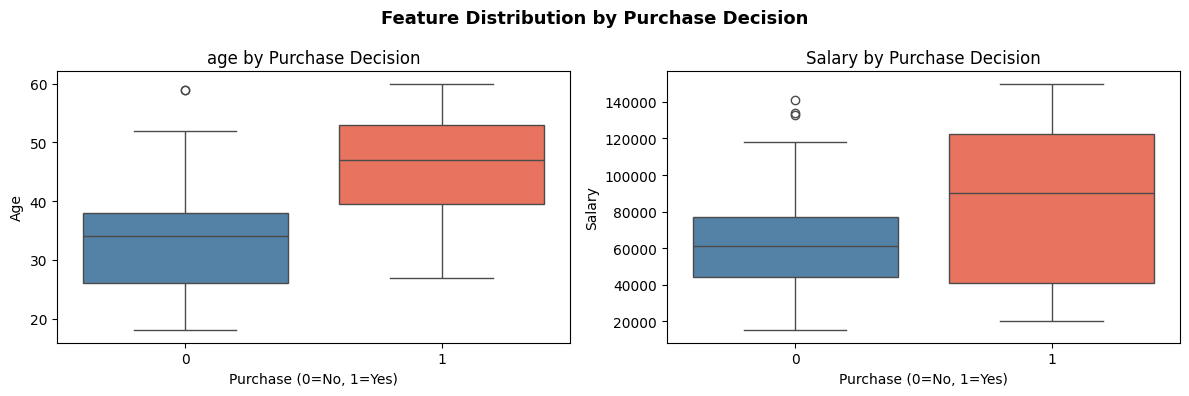

In [ ]:
fig, axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle("Feature Distribution by Purchase Decision", fontsize=13, fontweight='bold')
sns.boxplot(data=data, x='Purchase Iphone', y='Age', palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_title("age by Purchase Decision")
axes[0].set_xlabel("Purchase (0=No, 1=Yes)")
axes[0].set_ylabel("Age")

#salary distribution
sns.boxplot(data=data, x='Purchase Iphone', y='Salary', palette=["steelblue", "tomato"], ax=axes[1])
axes[1].set_title("Salary by Purchase Decision")
axes[1].set_xlabel("Purchase (0=No, 1=Yes)")
axes[1].set_ylabel("Salary")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Training set size:", X_train.shape[0])
print("Test set size    :", X_test.shape[0])

Training set size: 320
Test set size    : 80


In [ ]:
X= data.iloc[:, [1,2]].values
y=data.iloc[:, -1].values
print(f"Feature Matrix Shape:{X.shape} , Target array shape{y.shape}")

Feature Matrix Shape:(400, 2) , Target array shape(400,)


In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Training set size:", X_train.shape[0])
print("Test set size    :", X_test.shape[0])

Training set size: 320
Test set size    : 80


In [ ]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

In [ ]:
X_train= sc.fit_transform(X_train)
X_test= sc.transform(X_test)

In [ ]:
print("Training set ( first 3 rows after scaling): ")
print(np.round(X_train))

Training set ( first 3 rows after scaling): 
[[-1. -0.]
 [-1. -1.]
 [ 0.  0.]
 [ 2. -1.]
 [ 0. -0.]
 [ 0.  0.]
 [ 2.  0.]
 [ 0. -0.]
 [-0.  0.]
 [-0.  0.]
 [-1. -0.]
 [-2. -1.]
 [-1.  1.]
 [-1. -1.]
 [ 1. -1.]
 [ 1. -1.]
 [ 0.  1.]
 [-0.  1.]
 [-0.  1.]
 [ 0.  0.]
 [ 1. -1.]
 [-0. -2.]
 [-2. -1.]
 [ 0.  1.]
 [-0.  2.]
 [-0. -1.]
 [-2. -0.]
 [-0.  1.]
 [ 1. -1.]
 [-1. -0.]
 [-0.  0.]
 [ 0. -0.]
 [-0.  1.]
 [ 2. -0.]
 [-1. -1.]
 [-0.  0.]
 [-0. -0.]
 [-0. -1.]
 [ 1.  1.]
 [-1. -0.]
 [ 0.  2.]
 [-1. -2.]
 [-1. -2.]
 [-1.  0.]
 [ 1.  1.]
 [-1. -0.]
 [-1.  0.]
 [-0.  1.]
 [ 2.  0.]
 [-0.  1.]
 [-0. -1.]
 [ 1. -1.]
 [-1. -0.]
 [-0. -0.]
 [-1.  0.]
 [-0.  2.]
 [-1. -0.]
 [-0.  2.]
 [-1. -1.]
 [ 0. -0.]
 [-1. -2.]
 [ 2. -1.]
 [ 1.  2.]
 [-1.  1.]
 [ 1.  2.]
 [-1. -0.]
 [ 2.  0.]
 [ 1.  1.]
 [ 1. -1.]
 [ 1.  1.]
 [ 1.  0.]
 [-1.  2.]
 [ 2. -1.]
 [-0. -1.]
 [ 0.  0.]
 [-0. -0.]
 [ 0. -0.]
 [ 2. -1.]
 [-0.  1.]
 [ 1.  2.]
 [ 0.  2.]
 [-0.  0.]
 [ 0. -1.]
 [ 0.  0.]
 [ 2.  1.]
 [-1. -2.]
 [-1.  0.

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
classifier=GaussianNB()
classifier.fit(X_train, y_train)

print("Model trained Succesfully")
print("Classes learnes:",classifier.classes_)
print("Prior probabilities:", np.round(classifier.class_prior_, 3)) #this is the probability of the model for all three features

y_pred=classifier.predict(X_test)
print("Predicted labels (first 10):", y_pred[:10])
print("Actual labels (first 10):", y_test[:10])

Model trained Succesfully
Classes learnes: [0 1]
Prior probabilities: [0.644 0.356]
Predicted labels (first 10): [1 0 0 1 0 1 0 1 1 0]
Actual labels (first 10): [1 0 0 0 0 1 0 1 0 0]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix ")
print(cm)

confusion matrix 
[[47  4]
 [ 6 23]]


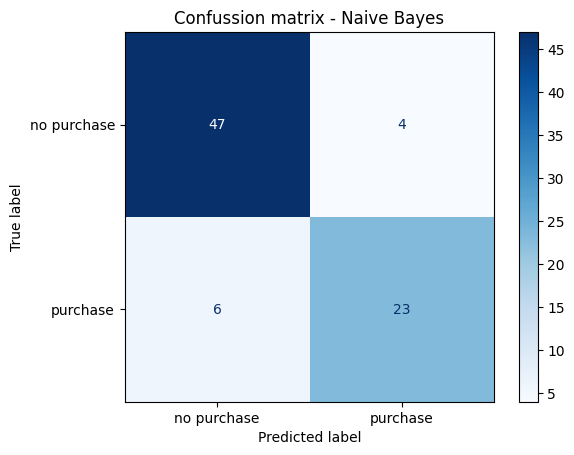

In [ ]:
disp= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no purchase', 'purchase'])
disp.plot(cmap="Blues")
plt.title("Confussion matrix - Naive Bayes")
plt.show()

In [ ]:
#accuracy= tp+tn / all 4 
#recall= tp/ tp + fp it is like the from the purchase i predicted how many are right (sales Guy)
#precesion = tp /tp+fn and it is like from the actual value how many prediction are right
#f1-score= 2(precison*recall)/precision + recall
from sklearn.metrics import accuracy_score
acc= accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"Accuracy: {acc*100:.2f}%")

from sklearn.metrics import classification_report
print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

Accuracy: 0.8750
Accuracy: 87.50%
Classification Report: 
              precision    recall  f1-score   support

 No Purchase       0.89      0.92      0.90        51
    Purchase       0.85      0.79      0.82        29

    accuracy                           0.88        80
   macro avg       0.87      0.86      0.86        80
weighted avg       0.87      0.88      0.87        80

